In [1]:
import os
import mlflow

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_pickle('../data/clean_data.pkl').sample(frac=0.1, random_state = 2)
df.info()
df=df.rename(columns={'income':'target'})
df['target'] = df['target'].apply(lambda x: 0 if x == '<=50K' \
                             else 1) 
df=df.drop(columns=['fnlwgt','education','native.country'])
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df['target'], test_size=0.25, random_state=2)


<class 'pandas.core.frame.DataFrame'>
Index: 3256 entries, 16054 to 17739
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             3256 non-null   int64   
 1   workclass       3256 non-null   category
 2   fnlwgt          3256 non-null   int64   
 3   education       3256 non-null   category
 4   education.num   3256 non-null   int64   
 5   marital.status  3256 non-null   category
 6   occupation      3256 non-null   category
 7   relationship    3256 non-null   category
 8   race            3256 non-null   category
 9   sex             3256 non-null   category
 10  capital.gain    3256 non-null   int64   
 11  capital.loss    3256 non-null   int64   
 12  hours.per.week  3256 non-null   int64   
 13  native.country  3256 non-null   category
 14  income          3256 non-null   category
dtypes: category(9), int64(6)
memory usage: 207.5 KB


In [3]:
cat_features = X_train.select_dtypes(include=['category','object']).columns.to_list()
cat_features


['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex']

In [4]:
num_features = X_train.select_dtypes(include=['number']).columns.to_list()
num_features

['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

In [5]:
from sklearn.ensemble import RandomForestClassifier
s_scaler = StandardScaler()
l_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=99999999)
classifier=RandomForestClassifier()

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features), 
        ('cat', l_encoder, cat_features), 
    ],
    remainder='drop' )

In [7]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model',classifier)])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['workclass',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex'])])),
                ('model', RandomForestClassifier())])

In [8]:
from mlflow.models import infer_signature
input_example = X_train.head(5)
signature =  infer_signature(model_input = X_train.head(5))

/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [9]:
y_test

17875    0
16235    0
23435    0
17989    1
10837    0
        ..
22774    0
13796    0
24066    0
24139    1
24324    0
Name: target, Length: 814, dtype: category
Categories (2, int64): [0, 1]

In [10]:
predictions = pipeline.predict(X_test) 

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

{'mae': 0.15724815724815724,
 'mape': 359624048868651.4,
 'mse': 0.15724815724815724}

In [11]:
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

registry_uri = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"
tracking_uri = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"

mlflow.set_tracking_uri(tracking_uri)   
mlflow.set_registry_uri(registry_uri)   

In [12]:
EXPERIMENT_NAME = "estate_project"
RUN_NAME = "baseline model"
REGISTRY_MODEL_NAME = "estate_model_rf"

In [13]:
from mlflow.models import infer_signature

signature =  infer_signature(model_input = X_train.head(5))
input_example = X_train.head(5)
req_file = '../requirenments.txt'
art = '../comment.txt'
params_dict = pipeline.get_params()
#experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

# Впоследствии. чтобы добавлять запуски в этот же эксепримент мы должны получить его id:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(params_dict)

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [14]:
from sklearn.preprocessing import QuantileTransformer, SplineTransformer, PolynomialFeatures, MinMaxScaler

X_train_fe_sklearn = X_train.copy()

In [15]:
pf = PolynomialFeatures(degree=2)
X_train_fe_sklearn
pf.fit_transform(X_train_fe_sklearn[['capital.gain','capital.loss']])

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 1.4710000e+03, 0.0000000e+00, 2.1638410e+06,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [1.0000000e+00, 7.2980000e+03, 0.0000000e+00, 5.3260804e+07,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]])

In [16]:
# Значения преобразованных признаков нужно отскейлить, поэтому создаем pipeline из двух шагов - преобразование и скейлинг
pf_pipeline = Pipeline(steps=[
    ('poly', pf),
    ('scale', StandardScaler())
])

preprocessor_sklearn = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features),  # преобразования для числовых признаков
        ('cat', l_encoder, cat_features), # преобразования для категориальных признаков
        ('poly', pf_pipeline, ['capital.gain','capital.loss']), # В преобразования добавляем созданный ранее pipeline
    ],
    remainder='drop',
    ) # Удаляем столбцы, которые не затронуты преобразования

In [17]:
X_train_fe_sklearn[['capital.gain','capital.loss']] = X_train_fe_sklearn[['capital.gain','capital.loss']].astype('float128')
X_train_fe_sklearn[['capital.gain','capital.loss']] = X_train_fe_sklearn[['capital.gain','capital.loss']].astype('float128')

X_train_sklearn_raw = preprocessor_sklearn.fit_transform(X_train_fe_sklearn)
X_train_sklearn = pd.DataFrame(X_train_sklearn_raw, columns=preprocessor_sklearn.get_feature_names_out())

with pd.option_context('display.max_rows', 5, 'display.max_columns', None):
    display (X_train_sklearn)

,num__age,num__education.num,num__capital.gain,num__capital.loss,num__hours.per.week,cat__workclass,cat__marital.status,cat__occupation,cat__relationship,cat__race,cat__sex,poly__1,poly__capital.gain,poly__capital.loss,poly__capital.gain^2,poly__capital.gain capital.loss,poly__capital.loss^2
0,0.451223,1.087806,-0.154977,-0.233165,0.740469,3.0,2.0,9.0,0.0,4.0,1.0,0.0,-0.154977,-0.233165,-0.082112,0.0,-0.213869
1,-1.205208,-0.447254,-0.154977,-0.233165,-0.056246,3.0,4.0,1.0,3.0,4.0,0.0,0.0,-0.154977,-0.233165,-0.082112,0.0,-0.213869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2440,1.315447,-0.063489,-0.154977,-0.233165,-0.056246,1.0,0.0,7.0,1.0,4.0,1.0,0.0,-0.154977,-0.233165,-0.082112,0.0,-0.213869
2441,2.755822,-0.447254,-0.154977,-0.233165,-2.048035,0.0,2.0,0.0,0.0,4.0,1.0,0.0,-0.154977,-0.233165,-0.082112,0.0,-0.213869


In [18]:
pipeline_sklearn = Pipeline(steps=[
    ('transform', preprocessor_sklearn),
    ('model', classifier)
])

model_sklearn = pipeline_sklearn.fit(X_train, y_train)

model_sklearn


Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['workclass',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex']),
                                                 ('poly',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['capital.gain',
                                                   'capital.loss'])])),
                ('model', RandomForestClassifier())])

In [19]:
predictions = model_sklearn.predict(X_test) 
metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'fe_sklearn'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(model_sklearn, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2024/11/20 21:18:31 INFO mlflow.tracking._tracking_service.client: 🏃 View run fe_sklearn at: http://127.0.0.1:5000/#/experiments/1/runs/56807f46592f4bc4a6a727a1720797bd.
2024/11/20 21:18:31 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


In [20]:
X_train

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week
31099,45,Private,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50
16198,22,Private,9,Never-married,Adm-clerical,Own-child,White,Female,0,0,40
4118,34,Federal-gov,13,Never-married,Exec-managerial,Unmarried,Asian-Pac-Islander,Male,1471,0,40
4143,24,Local-gov,10,Never-married,Protective-serv,Unmarried,Other,Male,1151,0,40
13727,39,Federal-gov,9,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,50
...,...,...,...,...,...,...,...,...,...,...,...
25681,24,?,13,Divorced,?,Not-in-family,White,Female,0,0,40
25344,21,Private,9,Never-married,Craft-repair,Other-relative,White,Male,0,0,40
2834,38,Private,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,7298,0,50
15404,57,Federal-gov,10,Divorced,Other-service,Not-in-family,White,Male,0,0,40


In [63]:
regressor2 = RandomForestClassifier(n_estimators=10, max_depth=6)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                           ('model', regressor2)])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test) 
metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics



{'mae': 0.1375921375921376,
 'mape': 188111040946679.28,
 'mse': 0.1375921375921376}

In [64]:
RUN_NAME = 'smaller_model'

experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(pipeline.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2024/11/20 23:06:20 INFO mlflow.tracking._tracking_service.client: 🏃 View run smaller_model at: http://127.0.0.1:5000/#/experiments/1/runs/a36b622aba974664abe71f492ef2e099.
2024/11/20 23:06:20 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


In [66]:
RUN_NAME = 'no_model'
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id 
    mlflow.log_artifact(art)


run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

run_id = '371bc3ec119649b8930e18deef366b1f' # Указываем run id
mlflow.register_model(f"runs:/{run_id}/models", REGISTRY_MODEL_NAME)

# Можно регистрировать сразу при создании прогона

experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name='register_at_run', experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file,
                             registered_model_name = REGISTRY_MODEL_NAME # Указываем для какой модели регистрируем
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(pipeline.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')



2024/11/20 23:08:06 INFO mlflow.tracking._tracking_service.client: 🏃 View run no_model at: http://127.0.0.1:5000/#/experiments/1/runs/89863905a1db4cf7931c81321505e320.
2024/11/20 23:08:06 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.
Registered model 'estate_model_rf' already exists. Creating a new version of this model...
2024/11/20 23:08:06 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: estate_model_rf, version 1
Created version '1' of model 'estate_model_rf'.
Registered model 'estate_model_rf' already exists. Creating a new version of this model...
2024/11/20 23:08:07 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: estate_model_rf, version 2
Created version '2' of model 'estate_model_rf'.
2024/11/20 23:08:09 INFO mlflow.tracking._tracking_service.client: 🏃 View run regi

In [67]:
model_reg = mlflow.search_registered_models()
model_reg[0]

<RegisteredModel: aliases={}, creation_timestamp=1732133217202, description='', last_updated_timestamp=1732133287886, latest_versions=[<ModelVersion: aliases=[], creation_timestamp=1732133287886, current_stage='None', description='', last_updated_timestamp=1732133287886, name='estate_model_rf', run_id='a78de32a8c134566bbef3232821b8e31', run_link='', source='mlflow-artifacts:/1/a78de32a8c134566bbef3232821b8e31/artifacts/models', status='READY', status_message='', tags={}, user_id='', version='2'>], name='estate_model_rf', tags={}>

In [69]:

model_name = REGISTRY_MODEL_NAME
model_version = 1



In [23]:
from autofeat import AutoFeatRegressor
transformations = ["abs", "sqrt", "^2"] 

afreg = AutoFeatRegressor(verbose=1, feateng_steps=2, max_gb=8, transformations=transformations,feateng_cols=num_features)

import numpy as np

class AutoFeatWrapper():
    def __init__(self, feateng_cols, feateng_steps=1, max_gb=16, transformations=["1/", "exp", "log"], n_jobs=-1, verbose=1):
        self.feateng_cols = feateng_cols
        self.feateng_steps = feateng_steps
        self.max_gb = max_gb
        self.transformations = transformations
        self.n_jobs = n_jobs
        self.afreg = AutoFeatRegressor(feateng_cols=self.feateng_cols,
                                     feateng_steps=self.feateng_steps,
                                     max_gb=self.max_gb,
                                     transformations=self.transformations,
                                     n_jobs=self.n_jobs)
        
    def fit(self, X, y=None):
        self.afreg.fit(X, y)
        return self
    
    def transform(self, X):
        return self.afreg.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        # Преобразуем данные и возвращаем имена фичей из DataFrame
        transformed_X = self.afreg.transform(pd.DataFrame(np.zeros((1, len(self.feateng_cols))), columns=self.feateng_cols))
        return transformed_X.columns.tolist()

afreg_pipeline = Pipeline(steps=[
    ('autofeat', AutoFeatWrapper( feateng_steps=2, max_gb=16, transformations=transformations,feateng_cols=num_features)),
    ('scaler', StandardScaler()),
])

preprocessor_afr = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features),  # преобразования для числовых признаков
        ('cat', l_encoder, cat_features), # преобразования для категориальных признаков
        ('afr', afreg_pipeline, num_features), # преобразования autofeat
    ],
    remainder='drop', # Удаляем столбцы, которые не затронуты преобразованиями
    ) 

X_train_afr_raw =  preprocessor_afr.fit_transform(X_train,y_train)
X_train_afr = pd.DataFrame(X_train_afr_raw, columns=preprocessor_afr.get_feature_names_out())

with pd.option_context('display.max_rows', 5, 'display.max_columns', None):
    display (X_train_afr)



/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/autofeat/featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


,num__age,num__education.num,num__capital.gain,num__capital.loss,num__hours.per.week,cat__workclass,cat__marital.status,cat__occupation,cat__relationship,cat__race,cat__sex,afr__age,afr__education.num,afr__capital.gain,afr__capital.loss,afr__hours.per.week,afr__sqrt(capitalgain),afr__age*educationnum**2,afr__age*hoursperweek,afr__age**2*educationnum,afr__capitalgain**2*educationnum**2,afr__capitalloss**2*educationnum**2
0,0.451223,1.087806,-0.154977,-0.233165,0.740469,3.0,2.0,9.0,0.0,4.0,1.0,0.451223,1.087806,-0.154977,-0.233165,0.740469,-0.261472,1.174765,0.878175,0.673899,-0.076496,-0.199479
1,-1.205208,-0.447254,-0.154977,-0.233165,-0.056246,3.0,4.0,1.0,3.0,4.0,0.0,-1.205208,-0.447254,-0.154977,-0.233165,-0.056246,-0.261472,-0.916544,-0.940447,-0.963145,-0.076496,-0.199479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2440,1.315447,-0.063489,-0.154977,-0.233165,-0.056246,1.0,0.0,7.0,1.0,4.0,1.0,1.315447,-0.063489,-0.154977,-0.233165,-0.056246,-0.261472,0.490591,0.917999,1.133290,-0.076496,-0.199479
2441,2.755822,-0.447254,-0.154977,-0.233165,-2.048035,0.0,2.0,0.0,0.0,4.0,1.0,2.755822,-0.447254,-0.154977,-0.233165,-2.048035,-0.261472,0.683453,-0.575395,2.688516,-0.076496,-0.199479


In [26]:
pipeline_afr = Pipeline(steps=[('preprocessor', preprocessor_afr), 
                               ('model', classifier)])

pipeline_afr.fit(X_train, y_train)

/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/autofeat/featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['workclass',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex']),
                                                 ('afr',
                                                  Pipeline(steps=[('autofeat',
                                                                   <__main__.AutoFeatWrapper object at 0x7078e0b883a0>),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week'])])),
                ('model', RandomForestClassifier())])

In [27]:
predictions = pipeline_afr.predict(X_test) 

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

{'mae': 0.16953316953316952,
 'mape': 414950825617674.7,
 'mse': 0.16953316953316952}

In [28]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name='autofeat', experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(pipeline_afr, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(pipeline_afr.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2024/11/20 21:27:51 INFO mlflow.tracking._tracking_service.client: 🏃 View run autofeat at: http://127.0.0.1:5000/#/experiments/1/runs/2131a5bb8c5141e2bf48208876977475.
2024/11/20 21:27:51 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


In [29]:
from sklearn.feature_selection import RFE
X_train_afr

,num__age,num__education.num,num__capital.gain,num__capital.loss,num__hours.per.week,cat__workclass,cat__marital.status,cat__occupation,cat__relationship,cat__race,...,afr__education.num,afr__capital.gain,afr__capital.loss,afr__hours.per.week,afr__sqrt(capitalgain),afr__age*educationnum**2,afr__age*hoursperweek,afr__age**2*educationnum,afr__capitalgain**2*educationnum**2,afr__capitalloss**2*educationnum**2
0,0.451223,1.087806,-0.154977,-0.233165,0.740469,3.0,2.0,9.0,0.0,4.0,...,1.087806,-0.154977,-0.233165,0.740469,-0.261472,1.174765,0.878175,0.673899,-0.076496,-0.199479
1,-1.205208,-0.447254,-0.154977,-0.233165,-0.056246,3.0,4.0,1.0,3.0,4.0,...,-0.447254,-0.154977,-0.233165,-0.056246,-0.261472,-0.916544,-0.940447,-0.963145,-0.076496,-0.199479
2,-0.340983,1.087806,0.041274,-0.233165,-0.056246,1.0,4.0,3.0,4.0,1.0,...,1.087806,0.041274,-0.233165,-0.056246,0.901670,0.507112,-0.303266,-0.167909,-0.073371,-0.199479
3,-1.061170,-0.063489,-0.001418,-0.233165,-0.056246,2.0,4.0,10.0,4.0,3.0,...,-0.063489,-0.001418,-0.233165,-0.056246,0.767406,-0.694592,-0.834250,-0.858525,-0.075364,-0.199479
4,0.019111,-0.447254,-0.154977,-0.233165,0.740469,1.0,2.0,1.0,0.0,4.0,...,-0.447254,-0.154977,-0.233165,0.740469,-0.261472,-0.422000,0.479936,-0.267687,-0.076496,-0.199479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2437,-1.061170,1.087806,-0.154977,-0.233165,-0.056246,0.0,0.0,0.0,1.0,4.0,...,1.087806,-0.154977,-0.233165,-0.056246,-0.261472,-0.099845,-0.834250,-0.729761,-0.076496,-0.199479
2438,-1.277226,-0.447254,-0.154977,-0.233165,-0.056246,3.0,4.0,2.0,2.0,4.0,...,-0.447254,-0.154977,-0.233165,-0.056246,-0.261472,-0.945635,-0.993545,-0.991983,-0.076496,-0.199479
2439,-0.052908,1.087806,0.818673,-0.233165,0.740469,3.0,2.0,9.0,0.0,4.0,...,1.087806,0.818673,-0.233165,0.740469,2.329294,0.749895,0.413563,0.111079,0.000425,-0.199479
2440,1.315447,-0.063489,-0.154977,-0.233165,-0.056246,1.0,0.0,7.0,1.0,4.0,...,-0.063489,-0.154977,-0.233165,-0.056246,-0.261472,0.490591,0.917999,1.133290,-0.076496,-0.199479


In [31]:
rfe_selector = RFE(estimator=classifier, n_features_to_select=12, step = 0.2) #drop 20% of features each iteration
X_train_rfe = rfe_selector.fit_transform(X_train_afr,y_train)

In [32]:
X_train_afr_rfe = pd.DataFrame(X_train_rfe, columns=rfe_selector.get_feature_names_out())
X_train_afr_rfe

,num__age,num__education.num,num__hours.per.week,cat__marital.status,cat__occupation,cat__relationship,afr__age,afr__education.num,afr__age*educationnum**2,afr__age*hoursperweek,afr__age**2*educationnum,afr__capitalgain**2*educationnum**2
0,0.451223,1.087806,0.740469,2.0,9.0,0.0,0.451223,1.087806,1.174765,0.878175,0.673899,-0.076496
1,-1.205208,-0.447254,-0.056246,4.0,1.0,3.0,-1.205208,-0.447254,-0.916544,-0.940447,-0.963145,-0.076496
2,-0.340983,1.087806,-0.056246,4.0,3.0,4.0,-0.340983,1.087806,0.507112,-0.303266,-0.167909,-0.073371
3,-1.061170,-0.063489,-0.056246,4.0,10.0,4.0,-1.061170,-0.063489,-0.694592,-0.834250,-0.858525,-0.075364
4,0.019111,-0.447254,0.740469,2.0,1.0,0.0,0.019111,-0.447254,-0.422000,0.479936,-0.267687,-0.076496
...,...,...,...,...,...,...,...,...,...,...,...,...
2437,-1.061170,1.087806,-0.056246,0.0,0.0,1.0,-1.061170,1.087806,-0.099845,-0.834250,-0.729761,-0.076496
2438,-1.277226,-0.447254,-0.056246,4.0,2.0,2.0,-1.277226,-0.447254,-0.945635,-0.993545,-0.991983,-0.076496
2439,-0.052908,1.087806,0.740469,2.0,9.0,0.0,-0.052908,1.087806,0.749895,0.413563,0.111079,0.000425
2440,1.315447,-0.063489,-0.056246,0.0,7.0,1.0,1.315447,-0.063489,0.490591,0.917999,1.133290,-0.076496


In [33]:
rfe_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_afr), 
    ('rfe_extractor', RFE(estimator=classifier, n_features_to_select=12, step = 0.2)),
    ('model', classifier)
])

rfe_pipeline.fit(X_train, y_train)

/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/autofeat/featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['workclass',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex']),
                                                 ('afr',
                                                  Pipeline(steps=[('autofeat',
                                                                   <__main__.AutoFeatWrapper object at 0x7078e0b883a0>),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week'])])),
                ('rfe_extractor',
                 RFE(estimator=RandomForestClassifier(),
                     n_features_to_select=12, step=0.2)),
                ('model', RandomForestClassifier())])

In [34]:
predictions_rfe = rfe_pipeline.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions_rfe)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions_rfe)
metrics["mse"] = mean_squared_error(y_test, predictions_rfe)

metrics

{'mae': 0.1977886977886978,
 'mape': 442614213992186.3,
 'mse': 0.1977886977886978}

In [35]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'rfe_feature_selection'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(rfe_pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2024/11/20 21:36:16 INFO mlflow.tracking._tracking_service.client: 🏃 View run rfe_feature_selection at: http://127.0.0.1:5000/#/experiments/1/runs/946d9a6b910745f29f4d377d1b417cfc.
2024/11/20 21:36:16 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


In [36]:

rfe_skl_selector = RFE(estimator=classifier, n_features_to_select=12, step = 0.2) #drop 20% of features each iteration
X_train_skl_rfe = rfe_skl_selector.fit_transform(X_train_sklearn,y_train)

In [37]:
X_train_skl_rfe = pd.DataFrame(X_train_skl_rfe, columns=rfe_skl_selector.get_feature_names_out())
X_train_skl_rfe

,num__age,num__education.num,num__capital.gain,num__capital.loss,num__hours.per.week,cat__workclass,cat__marital.status,cat__occupation,cat__relationship,poly__capital.gain,poly__capital.gain^2,poly__capital.loss^2
0,0.451223,1.087806,-0.154977,-0.233165,0.740469,3.0,2.0,9.0,0.0,-0.154977,-0.082112,-0.213869
1,-1.205208,-0.447254,-0.154977,-0.233165,-0.056246,3.0,4.0,1.0,3.0,-0.154977,-0.082112,-0.213869
2,-0.340983,1.087806,0.041274,-0.233165,-0.056246,1.0,4.0,3.0,4.0,0.041274,-0.079023,-0.213869
3,-1.061170,-0.063489,-0.001418,-0.233165,-0.056246,2.0,4.0,10.0,4.0,-0.001418,-0.080221,-0.213869
4,0.019111,-0.447254,-0.154977,-0.233165,0.740469,1.0,2.0,1.0,0.0,-0.154977,-0.082112,-0.213869
...,...,...,...,...,...,...,...,...,...,...,...,...
2437,-1.061170,1.087806,-0.154977,-0.233165,-0.056246,0.0,0.0,0.0,1.0,-0.154977,-0.082112,-0.213869
2438,-1.277226,-0.447254,-0.154977,-0.233165,-0.056246,3.0,4.0,2.0,2.0,-0.154977,-0.082112,-0.213869
2439,-0.052908,1.087806,0.818673,-0.233165,0.740469,3.0,2.0,9.0,0.0,0.818673,-0.006096,-0.213869
2440,1.315447,-0.063489,-0.154977,-0.233165,-0.056246,1.0,0.0,7.0,1.0,-0.154977,-0.082112,-0.213869


In [38]:
rfe_cols = X_train_skl_rfe.columns.tolist()
rfe_cols

['num__age',
 'num__education.num',
 'num__capital.gain',
 'num__capital.loss',
 'num__hours.per.week',
 'cat__workclass',
 'cat__marital.status',
 'cat__occupation',
 'cat__relationship',
 'poly__capital.gain',
 'poly__capital.gain^2',
 'poly__capital.loss^2']

In [39]:
rfe_idx = rfe_skl_selector.support_
rfe_idx

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False,  True, False,  True, False,  True])

In [41]:
#Отбираемые столбцы нужно залогировать, иначе мы потеряем информацию о том, какие призныки выбраны
with open('rfe_skl_idx.txt', 'w+') as f:
    f.write(str(rfe_idx))
with open('rfe_skl_cols.txt', 'w+') as f:
    f.write(str(rfe_cols))

In [42]:
class ColumnExtractor(object):

    def __init__(self, cols):
        self.cols = cols

    def transform(self, X):
        return X[:,self.cols]
    
    def fit(self, X, y=None):
        return self

In [43]:
rfe_skl_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_sklearn), 
    ('rfe_extractor', ColumnExtractor(rfe_idx)),
    ('model', classifier)
])

rfe_skl_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['workclass',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex']),
                                                 ('poly',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['capital.gain',
                                                   'capital.loss'])])),
                ('rfe_extractor',
                 <__main__.ColumnExtractor object at 0x7078ddf329e0>),
                ('model', RandomForestClassifier())])

In [44]:
predictions_rfe_skl = rfe_skl_pipeline.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions_rfe_skl)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions_rfe_skl)
metrics["mse"] = mean_squared_error(y_test, predictions_rfe_skl)

metrics
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'rfe_skl_feature_selection'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(rfe_pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact('rfe_skl_cols.txt')
    mlflow.log_artifact('rfe_skl_idx.txt')
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2024/11/20 21:43:20 INFO mlflow.tracking._tracking_service.client: 🏃 View run rfe_skl_feature_selection at: http://127.0.0.1:5000/#/experiments/1/runs/ae1e8d3ab0ab4129ae20fe71eabcf3e2.
2024/11/20 21:43:20 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


In [45]:
from mlxtend.feature_selection import SequentialFeatureSelector 
#from sklearn.feature_selection import SequentialFeatureSelector

sfs = SequentialFeatureSelector(RandomForestRegressor(n_estimators=3), 
                                k_features=3,
                                forward=True,
                                floating=False, # True to drop selected features
                                scoring='neg_mean_absolute_error',
                                cv=2)

sfs.fit(X_train_sklearn,y_train)

selected_features_sfs = X_train_sklearn.loc[:, sfs.k_feature_names_]
selected_features_sfs


/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
/home/mainuser/LR1_SM/IIS_LR

,num__education.num,cat__marital.status,poly__capital.gain^2
0,1.087806,2.0,-0.082112
1,-0.447254,4.0,-0.082112
2,1.087806,4.0,-0.079023
3,-0.063489,4.0,-0.080221
4,-0.447254,2.0,-0.082112
...,...,...,...
2437,1.087806,0.0,-0.082112
2438,-0.447254,4.0,-0.082112
2439,1.087806,2.0,-0.006096
2440,-0.063489,0.0,-0.082112


In [46]:
rfe_sfs_idx = list(sfs.k_feature_idx_)
rfe_sfs_idx
rfe_sfs_col = list(sfs.k_feature_names_)
rfe_sfs_col


['num__education.num', 'cat__marital.status', 'poly__capital.gain^2']

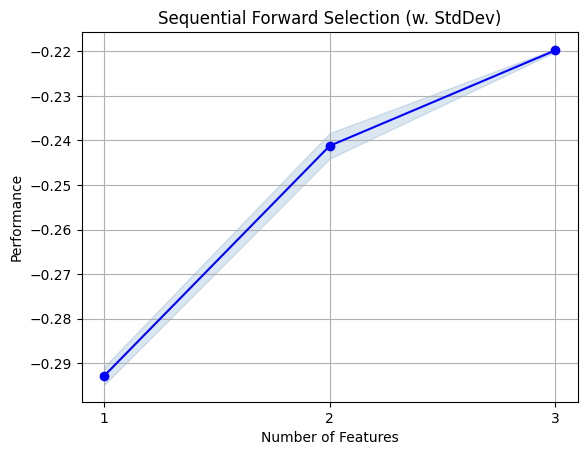

<Figure size 640x480 with 0 Axes>

In [47]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()
plt.savefig('Sequential Forward Selection')


In [48]:
rfe_sfs_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_sklearn), 
    ('rfe_extractor', ColumnExtractor(rfe_sfs_idx)),
    ('model', classifier)
])

rfe_sfs_pipeline.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['workclass',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex']),
                                                 ('poly',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['capital.gain',
                                                   'capital.loss'])])),
                ('rfe_extractor',
                 <__main__.ColumnExtractor object at 0x7078e0afa890>),
                ('model', RandomForestClassifier())])

In [49]:
predictions_sfs = rfe_sfs_pipeline.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions_sfs)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions_sfs)
metrics["mse"] = mean_squared_error(y_test, predictions_sfs)

metrics
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'rfe_sfs_feature_selection'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(rfe_sfs_pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact('rfe_skl_cols.txt')
    mlflow.log_artifact('rfe_skl_idx.txt')
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2024/11/20 21:47:16 INFO mlflow.tracking._tracking_service.client: 🏃 View run rfe_sfs_feature_selection at: http://127.0.0.1:5000/#/experiments/1/runs/f2584f582d044adfacb6441ddb732247.
2024/11/20 21:47:16 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


In [55]:
import optuna

import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import mlflow

def objective(trial):
    # Гиперпараметры для настройки
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    max_features = trial.suggest_float('max_features', 0.1, 1.0)

    # Создаем и обучаем модель
    opt_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', classifier)
    ])
    
    opt_pipeline.fit(X_train, y_train)

    # Предсказание и расчет метрики MAE
    preds = opt_pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae  # Минимизируем MAE

# Запускаем оптимизацию
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Выводим лучшие гиперпараметры
print('Number of finished trials:', len(study.trials))
print('Best trial:', study.best_trial.params)






[I 2024-11-20 22:07:44,433] A new study created in memory with name: no-name-da9d9f92-dc38-4248-8d16-165a09d04471


[I 2024-11-20 22:07:48,479] Trial 0 finished with value: 0.15601965601965603 and parameters: {'n_estimators': 143, 'max_depth': 14, 'max_features': 0.33563448985865846}. Best is trial 0 with value: 0.15601965601965603.
[I 2024-11-20 22:07:52,103] Trial 1 finished with value: 0.15847665847665848 and parameters: {'n_estimators': 300, 'max_depth': 5, 'max_features': 0.44555446362644135}. Best is trial 0 with value: 0.15601965601965603.
[I 2024-11-20 22:07:56,351] Trial 2 finished with value: 0.15356265356265356 and parameters: {'n_estimators': 196, 'max_depth': 14, 'max_features': 0.2758877183857713}. Best is trial 2 with value: 0.15356265356265356.
[I 2024-11-20 22:08:00,286] Trial 3 finished with value: 0.15233415233415235 and parameters: {'n_estimators': 211, 'max_depth': 11, 'max_features': 0.8852153849177934}. Best is trial 3 with value: 0.15233415233415235.
[I 2024-11-20 22:08:03,585] Trial 4 finished with value: 0.14987714987714987 and parameters: {'n_estimators': 207, 'max_depth':

Number of finished trials: 10
Best trial: {'n_estimators': 207, 'max_depth': 5, 'max_features': 0.5538362430146772}


In [58]:
# Используем оптимальные параметры
best_params = study.best_trial.params
opt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',classifier)
])

opt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['workclass',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex'])])),
                ('model', RandomForestClassifier())])

In [59]:
predictions = opt_pipeline.predict(X_test) 

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

{'mae': 0.16461916461916462,
 'mape': 387287437243163.06,
 'mse': 0.16461916461916462}

In [60]:
RUN_NAME = 'optuna_model'
with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(opt_pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')


2024/11/20 22:09:54 INFO mlflow.tracking._tracking_service.client: 🏃 View run optuna_model at: http://127.0.0.1:5000/#/experiments/1/runs/a3dc0d84e8524e28b66d1b5fd10dcda5.
2024/11/20 22:09:54 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


In [73]:
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)
X_train_sklearn = X_full.copy()


# Выбираем 2-3 числовых признака для создания полиномиальных признаков
numeric_features = ["education.num" ,"capital.gain","capital.loss"]  # Замените на имена числовых признаков
# Определяем трансформации
transformers=[
    ('num', s_scaler, num_features),  # преобразования для числовых признаков
    ('cat', l_encoder, cat_features), # преобразования для категориальных признаков
]
# Полиномиальные признаки
if numeric_features:
    transformers.append(
        ("poly", Pipeline([
            ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
            ("scaler", StandardScaler())  # Шкалируем полиномиальные признаки
        ]), numeric_features)
    )

preprocessor = ColumnTransformer(transformers=transformers, remainder="passthrough")

# Применяем трансформации к X_train_sklearn
X_train_fe_sklearn = preprocessor.fit_transform(X_train_sklearn)

# Сохраняем имена столбцов
column_names = preprocessor.get_feature_names_out()
pd.DataFrame(column_names).to_csv("column_names_final.csv", index=False)  # Сохраняем в файл



X_transformed_df = pd.DataFrame(X_train_fe_sklearn, columns=preprocessor.get_feature_names_out())


# Шаг 3: Создаем Pipeline для модели
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ('model', classifier)  # Замените на вашу модель
])

# Обучаем модель
final_model = pipeline.fit(X_full, y_full)

input_example = X_full.head(5)
RUN_NAME = 'final_model'
with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
        # получаем уникальный идентификатор запуска эксперимента
        run_id = run.info.run_id 
        mlflow.sklearn.log_model(pipeline, 
                                    artifact_path="models",
                                    signature=signature,
                                    input_example=input_example,
                                    pip_requirements=req_file
                                )
        mlflow.log_params(model_sklearn.get_params())
        mlflow.log_artifact("column_names_final.csv", artifact_path="columns")
        
run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')




2024/11/20 23:27:57 INFO mlflow.tracking._tracking_service.client: 🏃 View run final_model at: http://127.0.0.1:5000/#/experiments/1/runs/4cf9d4719df04b599bf5c26358948d19.
2024/11/20 23:27:57 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.
